In [122]:
import pickle
import config
import hypernet
import argparse
# 手动创建 argparse.Namespace 对象
args = argparse.Namespace(
    dataset='TKY',
    # baseline='LinUCB',
    time_embedding="glove",
    train=True,
    user_input=False,
    sample_rate=1.0,
    rank=-1,
    feature="glove_pca",
    gpu=2,
    train_window=5000,
    # result_path="./TOIS_result_new/",
    warm_start=False,  # 默认 False，使用 `store_true` 方式时
    isupdate=False,
    is_hypernet=False
)

hypernet_setting = config.hypernet_setting(args)

In [123]:
dataset = hypernet_setting.dataset
with open("./model_log/mlp_{}_rank_-1.pkl".format(dataset), "rb") as f:       # mlp_kuai_rank_-1 model_trained_7.0
    mlp = pickle.load(f).to("cuda:0")


# mlp = hypernet.MLP(hypernet_setting.input_dim ,  hypernet_setting.hidden_dim, hypernet_setting.output_dim).to("cuda:0")

In [124]:
import util
import torch
import numpy as np
import config
import hypernet
import random
import argparse

_, _, _, Timevectors = util.read_in_observed_feature(args.dataset,args.feature)
# mlp = hypernet.MLP(hypernet_setting.input_dim ,  hypernet_setting.hidden_dim, hypernet_setting.output_dim).to("cuda:0")

SVE = []
for timekey in Timevectors:
    print(timekey)
    input_tensor = hypernet.hypernetwork_input_building(timekey,Timevectors,user_info=None,hypernet_setting =hypernet_setting).to("cuda:0")

    input_tensor = input_tensor[:hypernet_setting.input_dim]
    #随机打乱input
    # input_tensor = input_tensor[torch.randperm(input_tensor.size()[0])]
    # print(input_tensor[0])
    # 利用超网络生成Theta
    # print(input_tensor)
    print("input_tensor",input_tensor)
    output = mlp(input_tensor)
    #numpy 增加维度
    output = output.detach().cpu().numpy()
    print("output",output[:5])
    Theta_Matrix = util.output_transform(output, hypernet_setting)
    # print(Theta_Matrix[1,:])
    Theta = Theta_Matrix
    U, s, V = np.linalg.svd(Theta)
    noise = np.random.normal(loc=0.1 * np.mean(s), scale=0.1 * np.mean(s), size=s.shape)  # 以 5% 的均值为标准差的高斯噪声
    s_perturbed = s + noise  # 加性扰动
    # 排序
    s_perturbed = np.sort(s_perturbed)[::-1]
    SVE.append(s_perturbed)
    print("s:", s[:5])
    print("s_perturbed:", s_perturbed[:10])

Mon morning
input_tensor tensor([-2.8924e-01,  1.7799e-01, -1.2570e+00,  3.0801e-01, -7.8455e-01,
         2.3067e-01,  4.8224e-02,  3.7995e-01,  8.8050e-03,  6.6985e-02,
         2.5798e-07, -3.7253e-09, -1.0058e-07, -9.6858e-08, -3.7253e-08,
         1.1921e-07,  4.4703e-08, -2.3283e-07,  1.8254e-07,  0.0000e+00,
         4.4703e-08, -4.8429e-08, -1.4901e-08,  8.1956e-08, -2.2352e-08,
         7.4506e-09, -7.4506e-09,  1.6764e-08, -3.7253e-09,  4.2841e-08],
       device='cuda:0')
output [ 1.889388   -0.55843145  0.4045982  -0.772454   -0.40837872]
s: [29.112165   8.299405   5.165235   2.923708   1.6969043]
s_perturbed: [29.22367493  8.10785628  5.55101751  3.09927984  1.93228766  1.9019746
  1.20014699  0.80287368  0.64884197  0.58012191]
Mon noon
input_tensor tensor([-1.2757e+00, -1.3054e+00,  2.1937e-01, -3.9409e-01, -3.6141e-01,
         7.1475e-02,  2.0438e-01,  4.1295e-01,  1.7999e-02,  7.7646e-02,
         1.7881e-07, -8.5682e-08, -1.6391e-07, -2.7940e-08,  2.0117e-07,
       

In [125]:
count = np.zeros(25)
for line in SVE:
    square_sums = []
  
    for row in range(25): # 前n个数据
        square_sum = sum([x**2 for x in line[:row+1]])
        square_sums.append(square_sum)
    for i in range(len(square_sums)):
        square_sums[i] = square_sums[i]/square_sums[-1]
    print(square_sums)

    for i in range(len(square_sums)):
        if square_sums[i] > 0.99:#阈值
            count[i]+=1
            break
print(count)


[0.8793086349784969, 0.9469922839938382, 0.9787183977065593, 0.9886083287656202, 0.9924526108182972, 0.9961772233968477, 0.9976602213800071, 0.9983239126697083, 0.9987573731865718, 0.9991038787543656, 0.9994222579208766, 0.9995878762507883, 0.999696620208994, 0.9997806788502978, 0.9998391609809323, 0.9998971489548469, 0.999929573677496, 0.9999424845242993, 0.9999456142761459, 0.9999456402171744, 0.9999457121515017, 0.9999464448255304, 0.9999477297569422, 0.999965762727432, 1.0]
[0.8723634301956074, 0.9540199586028764, 0.9791572177701415, 0.9892155869523288, 0.9927245715308675, 0.9956499296108301, 0.9968719200994376, 0.9973361650508399, 0.9977174037979021, 0.9980725218112853, 0.9984117675535384, 0.9987053601551718, 0.9989824492806088, 0.9992186838048891, 0.9994263165639584, 0.9995472704437349, 0.9996409435669822, 0.9997212976437294, 0.9998004488936093, 0.9998746018365979, 0.9999184096792619, 0.9999515992883944, 0.999980046482542, 0.9999969090561325, 1.0]
[0.885252229134142, 0.9523254928

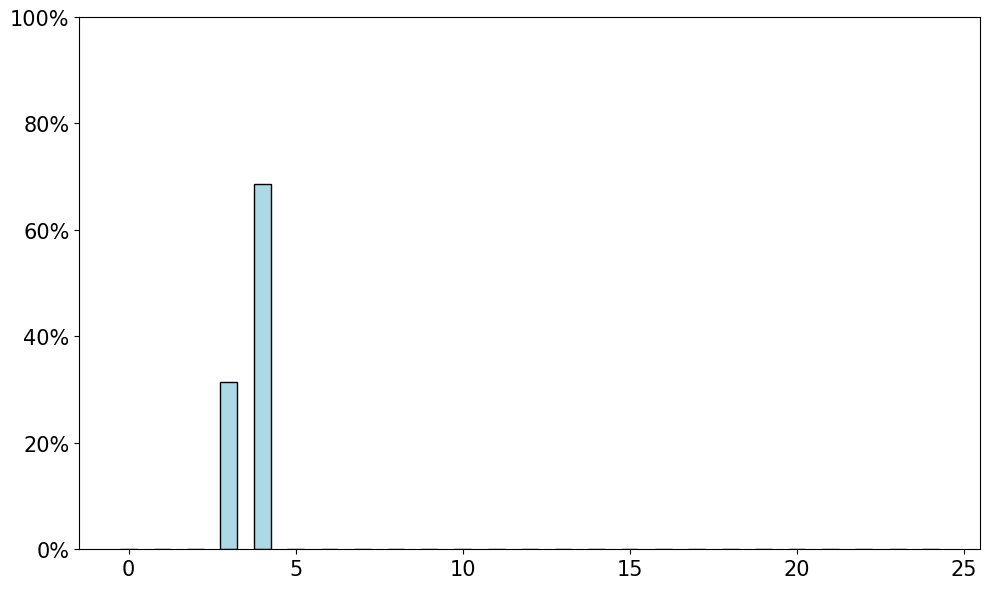

In [126]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
count  = count[:25]
count_sum = sum(count)
count = count/count_sum
plt.figure(figsize=(10, 6))
plt.ylim(0,1)

# from matplotlib.font_manager import FontProperties
# myfont = FontProperties(fname='times.ttf', size=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

colors = ['lightblue'] * 4#tomato
# /,  \, |, -, +, x, o, O,., * 。
plt.bar(np.arange(len(count)), count, ec=(0,0,0),  width=0.5,
        color=colors)
def to_percentage(y, position):
    return str(int(round(100 * y))) + '%'

# 设置y轴刻度标签的格式
plt.gca().yaxis.set_major_formatter(FuncFormatter(to_percentage))
plt.tight_layout()



plt.show()
# plt.savefig(f'pics/bar.png', format='png')  # 建议保存为svg格式,再用inkscape转为矢量图emf后插入word中


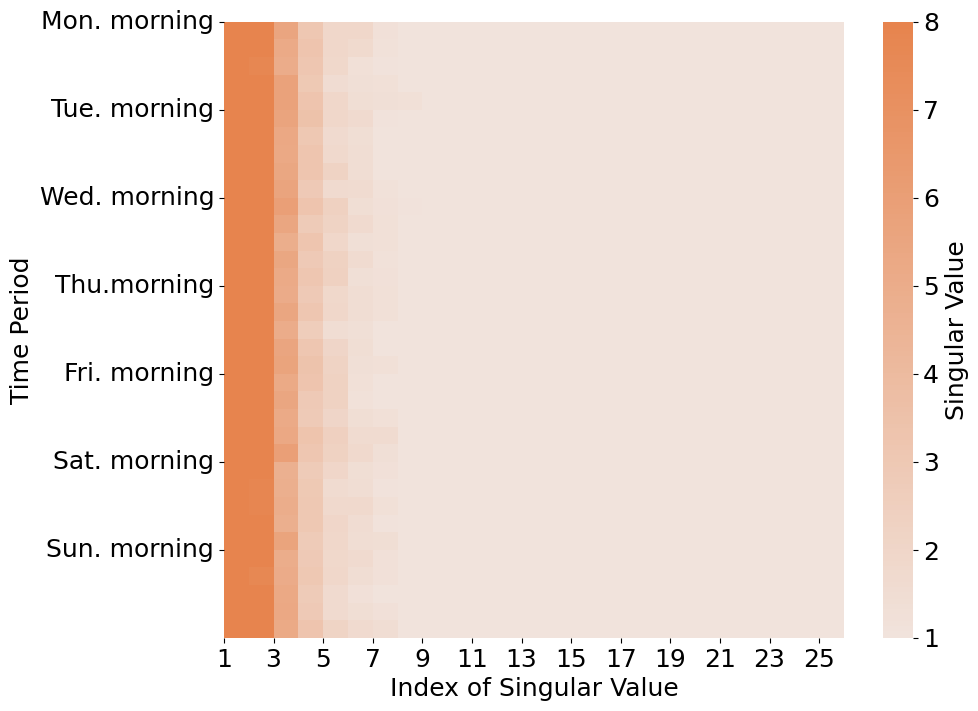

In [131]:

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 创建一个随机的 10x10 矩阵
data = SVE

# 设置颜色映射和中心值
cmap = sns.diverging_palette(10, 220, sep=80, as_cmap=True)
# 选择新的颜色映射（你可以换成下面推荐的其他 cmap）
cmap = sns.color_palette("coolwarm", as_cmap=True)  # 经典红蓝对比
cmap = sns.color_palette("magma", as_cmap=True)    # 深色高对比度
cmap = sns.color_palette("viridis", as_cmap=True)  # 适合色盲友好的方案
cmap = sns.color_palette("rocket", as_cmap=True)   # 现代红色调
cmap = sns.color_palette("crest", as_cmap=True)    # 现代蓝色调
cmap = sns.color_palette("flare", as_cmap=True)  # 红黄白
cmap = sns.diverging_palette(250, 30, l=65, center="light", as_cmap=True) 
center =0
plt.figure(figsize=(10, 8))
# 绘制热力图
sns.heatmap(data, cmap=cmap, center=center,vmin=1, vmax=8, annot=False,)#
ax = plt.gca()
# 获取图例对象
cbar = ax.collections[0].colorbar
cbar.set_label('Singular Value', fontsize=18)
# 调整图例刻度标签的字号大小
cbar.ax.tick_params(labelsize=18)


# ax.set_xticklabels(range(1,26)) 
x_labels = range(1, 26, 2)
ax.set_xticks(np.arange(0, 25, 2))
ax.set_xticklabels(x_labels,fontsize=18)
# ax.set_xticklabels(range(1,26))

y = list(Timevectors.keys())
for i in range(len(y)):
    if y[i] == "Mon morning":
        y[i] = "Mon. morning"
    elif y[i] == "Tue morning":
        y[i] = "Tue. morning"
    elif y[i] == "Wed morning":
        y[i] = "Wed. morning"
    elif y[i] == "Thu morning":
        y[i] = "Thu.morning"
    elif y[i] == "Fri morning":
        y[i] = "Fri. morning"
    elif y[i] == "Sat morning":
        y[i] = "Sat. morning"
    elif y[i] == "Sun morning":
        y[i] = "Sun. morning"
show_ticks = [True if i % 5 == 0 else False for i in range(len(y))]  # 每隔一行显示一个刻度标签

# ax.set_yticklabels(y)  # 设置所有刻度标签
plt.yticks(rotation=0)  # 旋转刻度标签

# 仅显示指定的刻度标签

plt.yticks(np.arange(len(y))[show_ticks], np.array(y)[show_ticks],fontsize=18)
# ax.set_yticklabels(y)
# ax.set_yticklabels(y[::2]) 
plt.xlabel("Index of Singular Value",fontsize=18)
plt.ylabel("Time Period",fontsize=18)
plt.savefig("./result_log/{}/{}_SVD.pdf".format(dataset,dataset), format='pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()
